# Define parameters

In [78]:
exec(open("./register slide to HR image defs.py").read())

# larger numbers will reduce noise and fine background patterns, but may reduce detail of image outlines
downscale_factor = 5  
slide_brightness_estimate = .9 # 0=black, 1=white
show_gradient_img = True                # True to show the gradient image used to find tissue outlines
show_mask_for_marker = False            # True to see where is considered a marker
increase_contrast_for_markers = False   # True when there is relatively even lighting
threshold_for_tissue = None             # None for automatic thresholding, integer [0,255] for manual

# Add the filepath to every image to be analyzed
image_paths = [r"C:\Users\elher\Downloads\MicrosoftTeams-image (13).png"]
    # r".\test_imgs\MicrosoftTeams-image.png",
    # r".\test_imgs\MicrosoftTeams-image (4).png",
    # r".\test_imgs\MicrosoftTeams-image (4)_cropped.png",
    # r".\test_imgs\MicrosoftTeams-image (5).png",
    # r".\test_imgs\MicrosoftTeams-image (5)_cropped.png",
    # r".\test_imgs\MicrosoftTeams-image (6).png",
    # r".\test_imgs\MicrosoftTeams-image (7).png",
    # r".\test_imgs\MicrosoftTeams-image (8).png",
    # r".\test_imgs\MicrosoftTeams-image (9).png",]

name_of_output_csv = 'output'

# Get the bounding boxes of the tissue sections

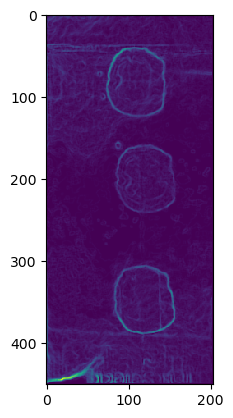

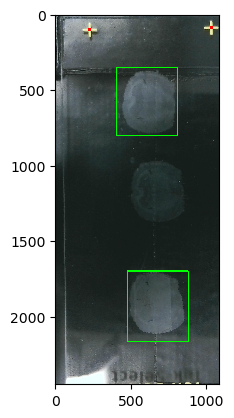

Output csv saved at C:\Users\elher\Downloads\output.csv


In [79]:
# Reference images of plus-shaped masks:
# This does not need to be modified
ref_imgs = [r".\reference-plus-sign1.npy",
            r".\reference-plus-sign2.npy"]

# will output a csv with bbox coordinates
# These coordinates are defined by a grid where markers are 
# (0,0) and (0,1) for the left and right markers respectively,
# when the markers are oriented upwards.

# will only work when the slide is centered and not slanted 
full_masks, bboxes, centerpoints, crude_centerpoints = get_tissue_regions_as_bbox(name_of_output_csv, image_paths, ref_imgs, downscale_factor,\
    slide_brightness_estimate = slide_brightness_estimate, show_gradient_img = show_gradient_img, show_mask_for_marker = show_mask_for_marker,\
    increase_contrast_for_markers = increase_contrast_for_markers, threshold_for_tissue = threshold_for_tissue)

# Visually examine the tissue masks

In [ ]:
show_processed_tissues(image_paths, full_masks, centerpoints)

In [ ]:
# show the masked images. Keep in mind the info passed to LabView are bounding boxes, not image masks.
for i in range(len(image_paths)):
    img = io.imread(image_paths[i])
    bounds = img.shape[1]//3, img.shape[1]*2//3
    img = img[:,bounds[0]:bounds[1]]
    show(img)
    for mask in full_masks[i]:
        masked_img = np.where(mask[:,:,None], img, [0,0,0])
        show(masked_img)

# Manually change things

In [ ]:
def get_tissue_regions_as_bbox(csv_name:str, image_paths:list, ref_imgs, downscale_factor:int = 5, img_indices: int or list = None):
    
    image_paths = determine_img_paths_to_use(image_paths, img_indices)
    
    full_masks_collector = []
    bboxes_collector = []
    centerpoints_collector = []
    c_collector = []

    for image_path in image_paths:
        # read image
        img_full = io.imread(image_path)
        bounds = img_full.shape[1]//3, img_full.shape[1]*2//3
        img_full = img_full[:,bounds[0]:bounds[1]]
        # img for finding markers
        # cropped_full_img = img_full[:img_full.shape[0]//3]

        # downsize images for speed and smoothing
        # determine new dimensions for downsized image
        # new_dim = np.flip(np.round(np.array(img_full.shape[0:2])/downscale_factor).astype(int))

        # use fewer thresholds when the background contrast is better
        min_thre, max_thre = .75, .9
        thresholds = np.linspace(min_thre, max_thre, num = int(np.round(((max_thre-min_thre)*50)+1)))
        size_thre = [img_full.size//8000, img_full.size//500] # empirically determined

        # get_plus_centerpoints from potential marker contours on thresholded images
        centerpoints = get_plus_centerpoints(ref_imgs, img_full, thresholds, size_thre)
        # centerpoints = get_plus_centerpoints(ref_imgs, cropped_full_img, thresholds, size_thre)

        # get the cluster assignments for ideal number of clusters
        cluster_assignments = determine_ideal_cluster_assignments(6, centerpoints)
        # get the centroid of the clusters as the location of the markers
        c1, c2 = get_mean_marker_centerpoints(centerpoints, cluster_assignments, as_int = False)

        # show_centerpoints(c1, c2, img_full)

        # determine the orientation of the slide based on the markers
        orientation, c1, c2 = determine_slide_orientation(img_full, c1, c2)

        # determine the region that may potenntially contain tissue sections
        bbox = find_rectangle_corners(img_full, c1, c2, orientation,  display = False)

        # crop image to potential tissue area
        img_cropped_full = img_full[bbox[0]:bbox[2], bbox[1]:bbox[3]]

        # determine how to downscale the cropped image
        new_dim_cropped = np.flip(np.round(np.array(img_cropped_full.shape[0:2])/downscale_factor).astype(int))

        # downsize the cropped image
        img_cropped_downsized = cv2.resize(img_cropped_full, new_dim_cropped, interpolation = cv2.INTER_AREA)
        img_cropped_downsized = (img_cropped_downsized/img_cropped_downsized.max()).astype(np.float32)

        # median blur image to eliminate spikes
        blur = cv2.medianBlur(img_cropped_downsized,5)

        # convert to LAB colorspace for better edge detection
        img_cropped_downsized_lab = cv2.cvtColor(blur, cv2.COLOR_BGR2LAB)

        # Get gradient of image using HyAB method
        cropped_downsized_hyab_gradient = get_hyab_gradient_img(img_cropped_downsized_lab)

        # get contours
        img_contours = get_contours(cropped_downsized_hyab_gradient, display = False)

        # get masks for downscaled lr img
        cropped_downsized_masks = get_final_tissue_masks(img_contours, cropped_downsized_hyab_gradient)
        cropped_downsized_masks = order_the_masks(cropped_downsized_masks, orientation_of_markers = orientation)

        # upscale masks to full size
        full_masks = upscale_imgs_back_to_orig(cropped_downsized_masks, img_full, img_cropped_full, bbox)
        # small_masks = [cv2.resize(i, new_dim_cropped, interpolation = cv2.INTER_AREA) for i in full_masks]

        # when the '+' markers are on the top of the image, the left is at (0,0) and the right is at (0,1)
        transform_matrix = determine_transform_to_new_coords(c1, c2)
        # print(full_masks)
        bboxes = get_tissue_bboxes_in_new_coordinate_plane(full_masks, transform_matrix)
        # print(bboxes)
        
        show_centerpoints_and_bboxes(img_full, c1, c2, full_masks)

        full_masks_collector.append(full_masks)
        bboxes_collector.append(bboxes)
        centerpoints_collector.append(centerpoints)
        c_collector.append((c1, c2))

    save_bboxes_as_csv(bboxes_collector, image_paths, csv_name)

    return full_masks_collector, bboxes_collector, c_collector, centerpoints_collector



In [27]:
def sharpen_image_for_marker_detection(full_img):
    # Normalize image to [0-1] and make it grayscale
    img = np.mean(full_img/full_img.max(), axis = 2)
    
    # remove spikes in signal
    spike_cutoff = np.quantile(img, .95)
    img = np.clip(img, 0, spike_cutoff)*spike_cutoff

    # Blur to remove abberations
    img = cv2.blur(img,(5,5),0)

    # increase contrast
    img = (((img/img.max())-.8)*2)+.8
    img = np.clip(img, 0, 1)

    # ensure the image is grayscale
    if len(img.shape) == 3:
        img = img.max(axis = 2)

    return img

In [28]:
def get_plus_centerpoints(reference_images, full_img, thresholds, size_thresholds):
    centerpoints = []

    img = sharpen_image_for_marker_detection(full_img)

    ref_imgs = get_reference_images(reference_images)

    # run for each provided threshold
    for thre in thresholds:
        # threshold image
        img_thre = np.where(img>thre, 255, 0).astype(np.uint8)
        show(img_thre)
        # show(img_thre)

        # Group contiguous sets of pixels
        labelled_grps = scipy.ndimage.label(img_thre, structure=np.ones((3,3)), output=None)[0]
        _, count = np.unique(labelled_grps, return_counts = True)

        # Draw an image that only contains the groups meeting the size and shape thresholds
        new_grp_img, group_idxs = remove_bad_groups(img_thre, labelled_grps, count, size_thresholds)
        # show(new_grp_img)

        IoUs = get_IoU_for_all_groups(new_grp_img, group_idxs, ref_imgs)
        # print(IoUs)

        # Sort IoUs
        sorted_IoUs = np.argsort(IoUs)
        # print(sorted_IoUs)
        # show(np.where(new_grp_img == group_idxs[sorted_IoUs[-1]], 255, 0))
        # show(np.where(new_grp_img == group_idxs[sorted_IoUs[-2]], 255, 0))
        # Get the centerpoints of the 2 most similar shapes to the references
        if sorted_IoUs.size:
            mask = np.where(new_grp_img == group_idxs[sorted_IoUs[-1]], 255, 0)
            c1 = scipy.ndimage.center_of_mass(mask, labels=None, index=None)
            centerpoints.append(c1)
        if sorted_IoUs.size>1:
            mask = np.where(new_grp_img == group_idxs[sorted_IoUs[-2]], 255, 0)
            c2 = scipy.ndimage.center_of_mass(mask, labels=None, index=None)
            centerpoints.append(c2)

    # print(centerpoints)
    return centerpoints

[0.95  0.965 0.98 ]


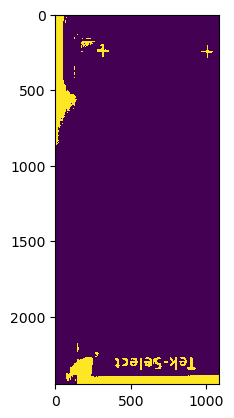

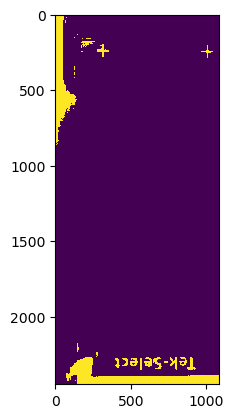

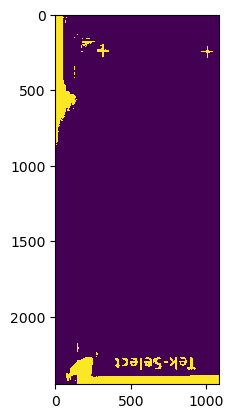

In [29]:
img_indices = None
image_paths = determine_img_paths_to_use(image_paths, img_indices)

full_masks_collector = []
bboxes_collector = []
centerpoints_collector = []
c_collector = []

for image_path in image_paths:
    # read image
    img_full = io.imread(image_path)
    bounds = img_full.shape[1]//3, img_full.shape[1]*2//3
    img_full = img_full[:,bounds[0]:bounds[1]]

    # img for finding markers
    # cropped_full_img = img_full[:img_full.shape[0]//3]

    # downsize images for speed and smoothing
    # determine new dimensions for downsized image
    # new_dim = np.flip(np.round(np.array(img_full.shape[0:2])/downscale_factor).astype(int))

    # use fewer thresholds when the background contrast is better
    min_thre, max_thre = .95, .98
    thresholds = np.linspace(min_thre, max_thre, num = int(np.round(((max_thre-min_thre)*50)+1)))
    print(thresholds)
    size_thre = [img_full.size//8000, img_full.size//500] # empirically determined

    # get_plus_centerpoints from potential marker contours on thresholded images
    centerpoints = get_plus_centerpoints(ref_imgs, img_full, thresholds, size_thre)
    # centerpoints = get_plus_centerpoints(ref_imgs, cropped_full_img, thresholds, size_thre)

    # get the cluster assignments for ideal number of clusters
    cluster_assignments = determine_ideal_cluster_assignments(6, centerpoints)
    # get the centroid of the clusters as the location of the markers
    c1, c2 = get_mean_marker_centerpoints(centerpoints, cluster_assignments, as_int = False)

    # show_centerpoints(c1, c2, img_full)

    # determine the orientation of the slide based on the markers
    orientation, c1, c2 = determine_slide_orientation(img_full, c1, c2)

    # determine the region that may potenntially contain tissue sections
    bbox = find_rectangle_corners(img_full, c1, c2, orientation,  display = False)

    # crop image to potential tissue area
    img_cropped_full = img_full[bbox[0]:bbox[2], bbox[1]:bbox[3]]

    # determine how to downscale the cropped image
    new_dim_cropped = np.flip(np.round(np.array(img_cropped_full.shape[0:2])/downscale_factor).astype(int))

    # downsize the cropped image
    img_cropped_downsized = cv2.resize(img_cropped_full, new_dim_cropped, interpolation = cv2.INTER_AREA)
    img_cropped_downsized = (img_cropped_downsized/img_cropped_downsized.max()).astype(np.float32)

    # median blur image to eliminate spikes
    blur = cv2.medianBlur(img_cropped_downsized,5)

    # convert to LAB colorspace for better edge detection
    img_cropped_downsized_lab = cv2.cvtColor(blur, cv2.COLOR_BGR2LAB)

    # Get gradient of image using HyAB method
    cropped_downsized_hyab_gradient = get_hyab_gradient_img(img_cropped_downsized_lab)
